<a href="https://colab.research.google.com/github/AjeySrini/capstone-project/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Make           Model   Type Origin DriveTrain      MSRP   Invoice  \
0  Acura             MDX    SUV   Asia        All  $36,945   $33,337    
1  Acura  RSX Type S 2dr  Sedan   Asia      Front  $23,820   $21,761    
2  Acura         TSX 4dr  Sedan   Asia      Front  $26,990   $24,647    
3  Acura          TL 4dr  Sedan   Asia      Front  $33,195   $30,299    
4  Acura      3.5 RL 4dr  Sedan   Asia      Front  $43,755   $39,014    

   EngineSize  Cylinders  Horsepower  MPG_City  MPG_Highway  Weight  \
0         3.5        6.0       265.0      17.0         23.0  4451.0   
1         2.0        4.0       200.0      24.0         31.0  2778.0   
2         2.4        4.0       200.0      22.0         29.0  3230.0   
3         3.2        6.0       270.0      20.0         28.0  3575.0   
4         3.5        6.0       225.0      18.0         24.0  3880.0   

   Wheelbase  Length  
0      106.0   189.0  
1      101.0   172.0  
2      105.0   183.0  
3      108.0   186.0  
4      115.0   197.

/tmp/ipykernel_1170/186248517.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.figure();df.groupby(df.select_dtypes(exclude='number').columns[0])[num[0]].mean().plot.bar();plt.tight_layout();plt.savefig("bar_plot.png")


         Var1       Var2      Diff
8        MSRP  Wheelbase  0.246145
80  Wheelbase       MSRP  0.246145
81  Wheelbase    Invoice  0.244519
                       mean           std  count
Make                                            
Acura          42938.571429  22189.007735      7
Audi           43307.894737  13533.663206     19
BMW            43285.250000  12459.756532     20
Buick          30537.777778   6371.656040      9
Cadillac       50474.375000  12552.254902      8
Chevrolet      26587.037037  10887.944574     27
Chrysler       27252.000000   5820.507403     15
Dodge          26253.846154  17614.497007     13
Ford           24015.869565   7952.490269     23
GMC            29560.500000   8781.579471      8
Honda          21434.705882   5303.739386     17
Hummer         49995.000000           NaN      1
Hyundai        17476.500000   5127.338713     12
Infiniti       36070.000000   8044.208209      8
Isuzu          26149.000000   8061.017306      2
Jaguar         61580.416667

/tmp/ipykernel_1170/186248517.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp=df.groupby(cat)[num[0]].agg(["mean","std","count"])


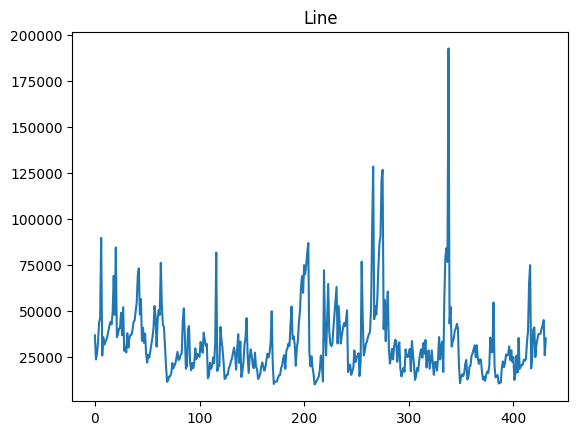

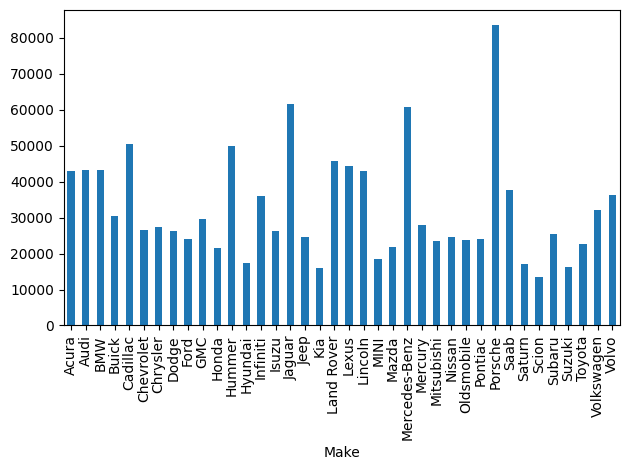

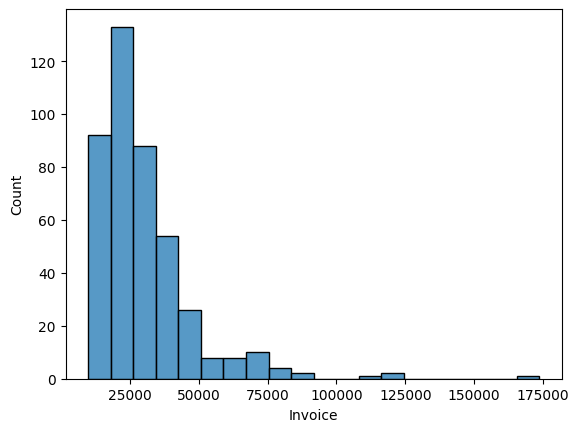

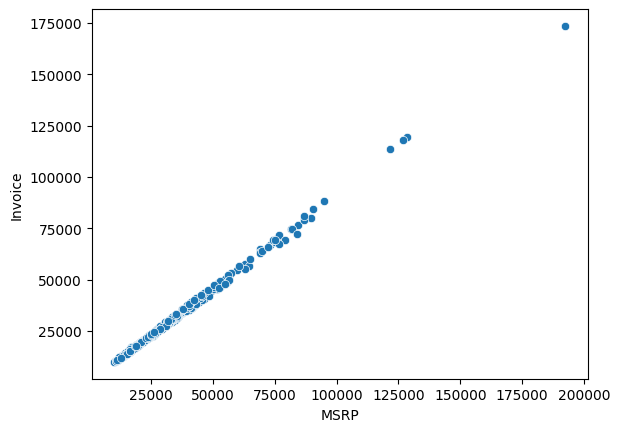

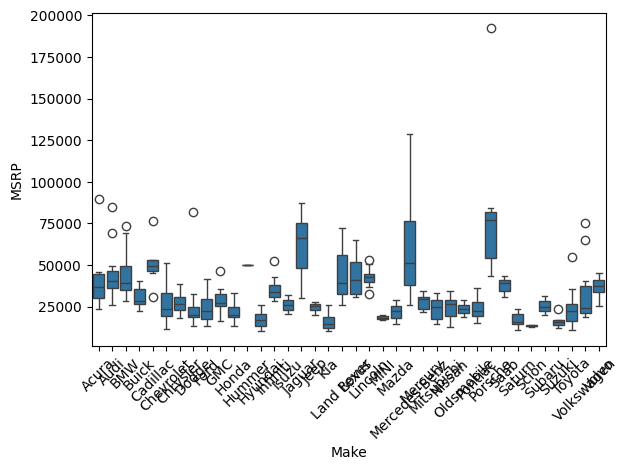

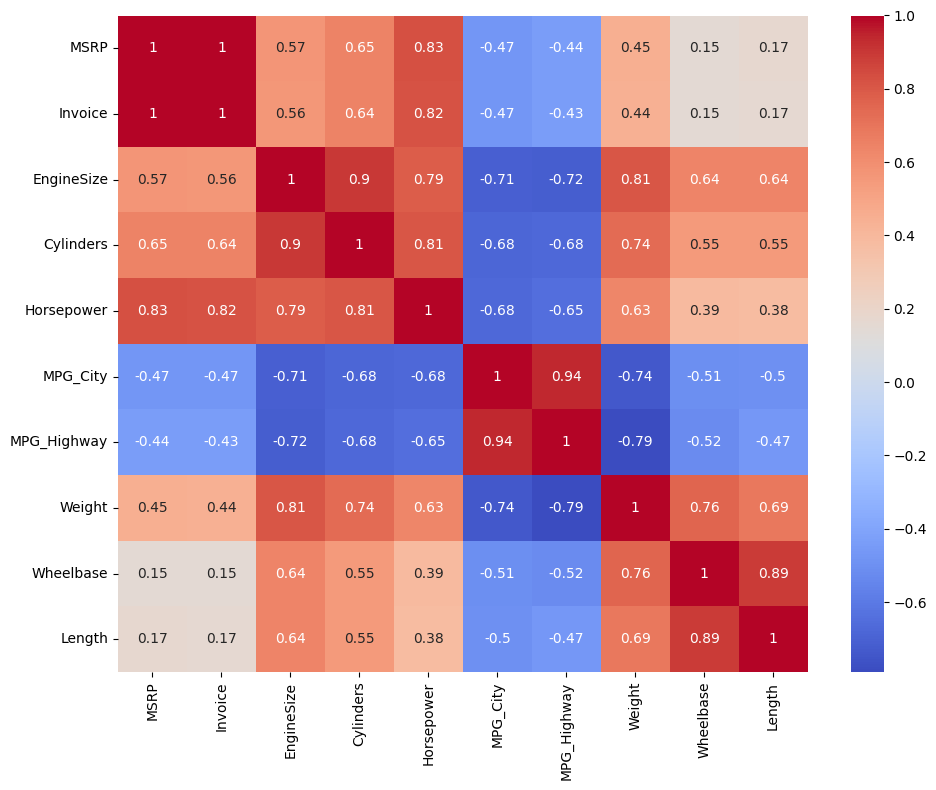

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Cars Data1.csv")
print(df.head())
print(df.dtypes)
print(df.shape)

nulls=pd.DataFrame({
    "Null Count":df.isnull().sum(),
    "Null %":df.isnull().mean()*100
})
print(nulls)

for c in ["MSRP","Invoice"]:
    if c in df.columns:
        df[c]=df[c].astype(str).str.replace("[$,]","",regex=True)
        df[c]=pd.to_numeric(df[c],errors="coerce")

for c in df.select_dtypes(include="object").columns:
    if df[c].nunique()/len(df)<0.5:
        df[c]=df[c].astype("category")

num=df.select_dtypes(include="number").columns
for c in num:
    if df[c].isnull().mean()<0.2:
        df[c]=df[c].fillna(df[c].median())

dups=df.duplicated().sum()
print("Duplicates:",dups)
df=df.drop_duplicates()

print(df.describe())
sk=df[num].skew().sort_values(key=abs,ascending=False)
print(sk)

for c in num[:2]:
    q1,q3=df[c].quantile([0.25,0.75]);iqr=q3-q1
    lb=q1-1.5*iqr;ub=q3+1.5*iqr
    print(c,((df[c]<lb)|(df[c]>ub)).sum())

plt.figure();df[num[0]].plot();plt.title("Line");plt.savefig("line_plot.png")
plt.figure();df.groupby(df.select_dtypes(exclude='number').columns[0])[num[0]].mean().plot.bar();plt.tight_layout();plt.savefig("bar_plot.png")
plt.figure();sns.histplot(df[sk.index[0]],bins=20);plt.savefig("histogram.png")
plt.figure();sns.scatterplot(x=df[num[0]],y=df[num[1]]);plt.savefig("scatter.png")
plt.figure();sns.boxplot(x=df.select_dtypes(exclude='number').columns[0],y=num[0],data=df);plt.xticks(rotation=45);plt.tight_layout();plt.savefig("boxplot.png")
plt.figure(figsize=(10,8));sns.heatmap(df[num].corr(),annot=True,cmap="coolwarm");plt.tight_layout();plt.savefig("heatmap.png")

pear=df[num].corr()
spear=df[num].corr(method="spearman")
diff=(spear-pear).abs().stack().reset_index()
diff.columns=["Var1","Var2","Diff"]
diff=diff[diff.Var1!=diff.Var2].sort_values("Diff",ascending=False)
print(diff.head(3))

cat=df.select_dtypes(exclude="number").columns[0]
grp=df.groupby(cat)[num[0]].agg(["mean","std","count"])
print(grp)

df.to_csv("cleaned_data.csv",index=False)


```markdown
# Project README: Car Data Analysis

This notebook performs an initial exploratory data analysis (EDA) on a dataset named `Cars Data1.csv`. The steps include data loading, initial inspection, handling missing values, data type conversions, duplicate removal, descriptive statistics, skewness analysis, outlier detection, and various visualizations to understand the data.

## 1. Data Loading and Initial Inspection

- **Code**: `df=pd.read_csv("Cars Data1.csv")`
- **Description**: Loads the `Cars Data1.csv` file into a pandas DataFrame named `df`.
- **Findings**: The dataset contains 432 entries and 15 columns.

- **Code**: `print(df.head())`
- **Description**: Displays the first 5 rows of the DataFrame to get a glimpse of the data.

- **Code**: `print(df.dtypes)`
- **Description**: Shows the data types of each column.
- **Findings**: 'MSRP' and 'Invoice' are initially of `object` type due to currency symbols, and other numerical columns are `float64`.

- **Code**: `print(df.shape)`
- **Description**: Prints the dimensions (rows, columns) of the DataFrame.
- **Findings**: (432, 15)

## 2. Missing Values Analysis

- **Code**: `nulls=pd.DataFrame({"Null Count":df.isnull().sum(), "Null %":df.isnull().mean()*100})`
- **Description**: Calculates the count and percentage of null values for each column and stores them in a DataFrame named `nulls`.
- **Findings**: All columns have a small number of missing values (4 to 6 nulls), representing approximately 0.93% to 1.39% of the data.

## 3. Data Cleaning - Type Conversion

- **Code**: `for c in ["MSRP","Invoice"]:...`
- **Description**: Converts the 'MSRP' and 'Invoice' columns from `object` (string) to `numeric` by removing '$' and ',' characters and then using `pd.to_numeric` with `errors="coerce"` to handle any remaining non-numeric values by converting them to `NaN`.

- **Code**: `for c in df.select_dtypes(include="object").columns:...`
- **Description**: Iterates through remaining `object` type columns. If the number of unique values in a column is less than 50% of the total number of rows, it converts that column's data type to `category`. This optimizes memory usage and can improve performance for categorical operations.

## 4. Data Cleaning - Imputation

- **Code**: `for c in num: if df[c].isnull().mean()<0.2: df[c]=df[c].fillna(df[c].median())`
- **Description**: For numerical columns (`num`), if the proportion of missing values is less than 20%, it imputes the missing values with the median of that column. This helps to retain data while minimizing the impact of outliers on central tendency.

## 5. Duplicate Handling

- **Code**: `dups=df.duplicated().sum(); print("Duplicates:",dups); df=df.drop_duplicates()`
- **Description**: Counts the number of duplicate rows in the DataFrame and then removes them.
- **Findings**: Initially, there were 3 duplicate rows. After removal, the DataFrame size changed to 429 rows.

## 6. Descriptive Statistics

- **Code**: `print(df.describe())`
- **Description**: Generates descriptive statistics (count, mean, std, min, max, quartiles) for all numerical columns.
- **Findings**: Provides a summary of the central tendency, dispersion, and shape of the distribution for each numerical feature. For example, 'MSRP' ranges from $10,280 to $192,465.

## 7. Skewness Analysis

- **Code**: `sk=df[num].skew().sort_values(key=abs,ascending=False); print(sk)`
- **Description**: Calculates the skewness for all numerical columns and sorts them by the absolute skewness value in descending order. Skewness indicates the asymmetry of the distribution.
- **Findings**: 'Invoice', 'MSRP', and 'MPG_City' show the highest absolute skewness values, suggesting they are heavily skewed.

## 8. Outlier Detection (IQR Method)

- **Code**: `for c in num[:2]: q1,q3=df[c].quantile([0.25,0.75]); iqr=q3-q1; lb=q1-1.5*iqr; ub=q3+1.5*iqr; print(c,((df[c]<lb)|(df[c]>ub)).sum())`
- **Description**: Applies the Interquartile Range (IQR) method to detect outliers for the first two numerical columns (MSRP and Invoice in this case). It calculates lower bound (lb) and upper bound (ub) and counts values falling outside these bounds.
- **Findings**: Both 'MSRP' and 'Invoice' columns have 27 identified outliers, indicating the presence of extremely high or low values.

## 9. Visualizations

This section generates several plots to visualize the data distributions and relationships.

- **Line Plot**: `df[num[0]].plot(); plt.title("Line"); plt.savefig("line_plot.png")`
  - **Description**: A line plot showing the values of the first numerical column ('MSRP') over the index. This can show trends or patterns in the order of data entry.
  - **Output**: `line_plot.png`

- **Bar Plot**: `df.groupby(df.select_dtypes(exclude='number').columns[0])[num[0]].mean().plot.bar(); plt.tight_layout(); plt.savefig("bar_plot.png")`
  - **Description**: A bar plot displaying the average of the first numerical column ('MSRP') grouped by the first categorical column ('Make'). It helps to compare the average MSRP across different car manufacturers.
  - **Output**: `bar_plot.png`

- **Histogram**: `sns.histplot(df[sk.index[0]],bins=20); plt.savefig("histogram.png")`
  - **Description**: A histogram of the most skewed numerical column ('Invoice') with 20 bins. This visualization shows the distribution of the data and confirms the skewness.
  - **Output**: `histogram.png`

- **Scatter Plot**: `sns.scatterplot(x=df[num[0]],y=df[num[1]]); plt.savefig("scatter.png")`
  - **Description**: A scatter plot showing the relationship between the first two numerical columns ('MSRP' and 'Invoice'). It visualizes the correlation and potential clusters or outliers.
  - **Output**: `scatter.png`

- **Box Plot**: `sns.boxplot(x=df.select_dtypes(exclude='number').columns[0],y=num[0],data=df); plt.xticks(rotation=45); plt.tight_layout(); plt.savefig("boxplot.png")`
  - **Description**: A box plot illustrating the distribution of the first numerical column ('MSRP') across different categories of the first categorical column ('Make'). This helps to identify variations and potential outliers within each category.
  - **Output**: `boxplot.png`

- **Heatmap**: `sns.heatmap(df[num].corr(),annot=True,cmap="coolwarm"); plt.tight_layout(); plt.savefig("heatmap.png")`
  - **Description**: A heatmap visualizing the Pearson correlation matrix of all numerical columns. `annot=True` displays the correlation coefficients on the map, and `cmap="coolwarm"` uses a diverging colormap to highlight positive and negative correlations.
  - **Output**: `heatmap.png`

## 10. Correlation Analysis (Pearson vs. Spearman)

- **Code**: `pear=df[num].corr(); spear=df[num].corr(method="spearman")`
- **Description**: Calculates both Pearson (linear) and Spearman (rank-based) correlation matrices for all numerical columns. Spearman correlation is more robust to outliers and non-linear relationships.

- **Code**: `diff=(spear-pear).abs().stack().reset_index(); diff.columns=["Var1","Var2","Diff"]; diff=diff[diff.Var1!=diff.Var2].sort_values("Diff",ascending=False); print(diff.head(3))`
- **Description**: Computes the absolute difference between the Pearson and Spearman correlation coefficients, stacks them, and sorts to find the pairs of variables with the largest discrepancy in correlation.
- **Findings**: The top 3 pairs with the largest differences in correlation coefficients are 'MSRP' and 'Wheelbase', and 'Wheelbase' and 'Invoice', suggesting that the relationship between these pairs might be non-linear or influenced by outliers.

## 11. Categorical Grouping Analysis

- **Code**: `cat=df.select_dtypes(exclude="number").columns[0]; grp=df.groupby(cat)[num[0]].agg(["mean","std","count"]); print(grp)`
- **Description**: Groups the DataFrame by the first categorical column ('Make') and calculates the mean, standard deviation, and count of the first numerical column ('MSRP') for each group.
- **Findings**: Provides insights into the average MSRP, variability (std), and number of entries for each car manufacturer. For example, 'Porsche' has a high mean MSRP and 'Hummer' only has one entry.

## 12. Export Cleaned Data

- **Code**: `df.to_csv("cleaned_data.csv",index=False)`
- **Description**: Saves the cleaned and processed DataFrame `df` to a new CSV file named `cleaned_data.csv`. The `index=False` argument prevents writing the DataFrame index as a column in the CSV.
- **Output**: `cleaned_data.csv`
```